# Mevsimsel Olmayan Zaman Serisi Tahminleri için Basit ARIMA Modeli

Bu zorluktaki hedefimiz, zaman serisi analizinin temel kavramlarını tek boyutlu verilere uygulamaktır

Bu zorluklarda şu adımları izleyeceğiz:
1. verileri yükleme ve görselleştirme;
2. modellerimizi eğitme ve tahminler yapma;

##  1. Veri Yükleme
Zorlukta kullanacağımız zaman serisini yükleyerek başlayalım. Veri setini CSV dosyası olarak indirmek için aşağıdaki satırı çalıştırın, ardından CSV'yi bir DataFrame'e yükleyin.

In [1]:
!curl https://d32aokrjazspmn.cloudfront.net/materials/www_usage.csv > data/www_usage.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   377  100   377    0     0   1724      0 --:--:-- --:--:-- --:--:--  1721


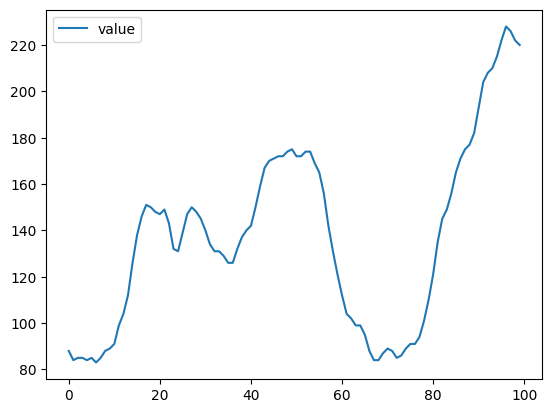

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/www_usage.csv', names=['value'], header=0)
y = df.value

df.plot();

Bu soyut zaman serisi mevsimsel görünmüyor, ancak artan bir trend ve bir şekilde "yapışkan" (yani biraz oto-regresif) özellikler gösteriyor. Bu nedenle Oto-Regresif Hareketli Ortalama (ARIMA) modelleri için iyi bir aday olabilir.

## 2. ARIMA Modeli Oluşturma
ARIMA modelleri (Oto Regresif Entegre Hareketli Ortalama) sayesinde verileri tahmin etmeye çalışacağız.

Bunun için şunları yapmamız gerekecek:
1. zaman serisini nasıl durağanlaştırılacağını bulma (ARIMA'daki I)
2. oto-regresif (AR) kısmını bulma
3. hareketli ortalama (MA) kısmını bulma
4. Uydurma
5. Performansı değerlendirme

### Adım 1 - Durağanlığı Sağlama

ARIMA modelleri yalnızca "durağan" zaman serilerine uygulanır.

👉 [`Genişletilmiş Dickey-Fuller testi`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) kullanarak durağanlığını kesin olarak kontrol edin, özellikle p-değerini

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller


df = pd.read_csv('data/www_usage.csv', names=['value'], header=0)
y = df.value


result = adfuller(y)

print(f'ADF İstatistiği : {result[0]:.4f}')
print(f'p-değeri        : {result[1]:.4f}')

if result[1] < 0.05:
    print('✅ Durağan! (p < 0.05)')
else:
    print('❌ Durağan değil! Fark almamız gerekiyor.')

ADF İstatistiği : -2.4642
p-değeri        : 0.1244
❌ Durağan değil! Fark almamız gerekiyor.


Durağanlıkta %95 güvenilirlik için p-değeri 0.05'ten küçük olmalıdır.
P-değeri 0.05'ten büyükse, boş hipotezi reddedemeriz (boş hipotez = "süreç durağan değildir").

Zaman serisi durağan değilse, **farklaştırma** yoluyla durağanlaştırılması gerekir.
- Bu, her değer ile bir önceki değer arasındaki farkı almak anlamına gelir (*birinci fark*).
- *İkinci fark* istiyorsanız, farklaştırılmış seri üzerinde işlemi tekrarlayın, vb...

👉 Durağan hale getirmek için ihtiyacımız olan minimum farklaştırma sırasını bulun (görselleştirmek için eğrileri çizin ve emin olmak için adfuller p-değerlerini yazdırın)

<details>
    <summary>İpucu</summary>

`pd.Series.diff`
</details>

1. fark p-değeri: 0.0703
2. fark p-değeri: 0.0000


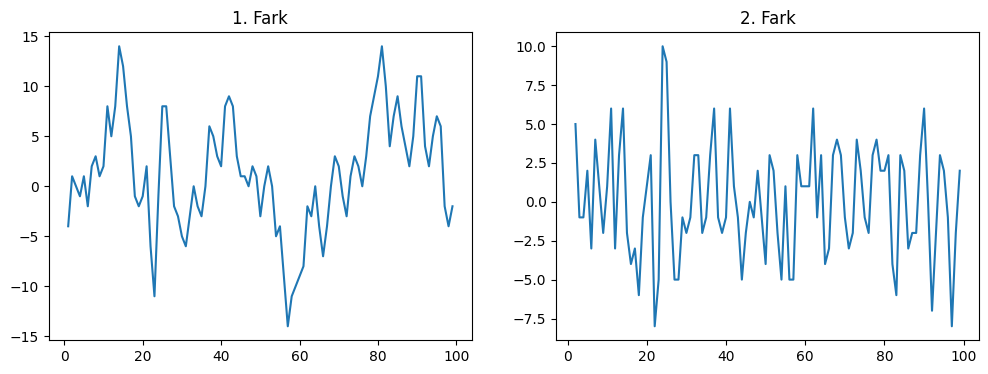

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


y_diff1 = y.diff().dropna()


y_diff2 = y.diff().diff().dropna()


p1 = adfuller(y_diff1)[1]
p2 = adfuller(y_diff2)[1]

print(f'1. fark p-değeri: {p1:.4f}')
print(f'2. fark p-değeri: {p2:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_diff1.plot(ax=axes[0], title='1. Fark')
y_diff2.plot(ax=axes[1], title='2. Fark')
plt.show()

Burada bir ve iki fark sırası arasında yakın bir durumumuz var. Zaman serilerini fazla farklaştırmak ARIMA modellerinizin performansını da düşürebilir. Daha yakından bakalım:

👉 1. ve 2. fark sırası için otokorelasyon grafiğini ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) çizin.

(💡Profesyonel ipucu: Her statsmodels grafiği örneklemesinin sonuna `;` ekleyerek veya `plt.show()` çağırarak statsmodels grafiklerinin çoğaltılmasından kaçının)

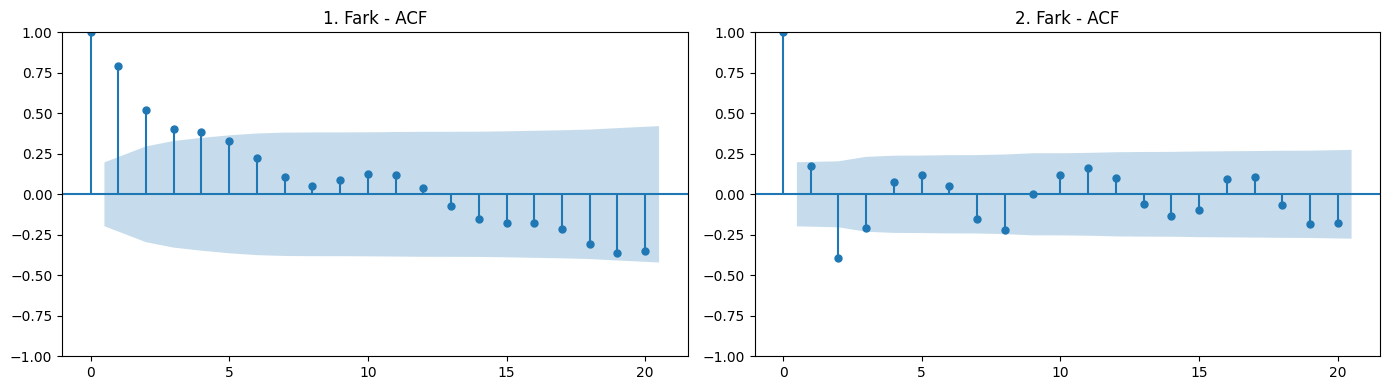

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y_diff1, lags=20, ax=axes[0], title='1. Fark - ACF');
plot_acf(y_diff2, lags=20, ax=axes[1], title='2. Fark - ACF');

plt.tight_layout()
plt.show()

"İkinci sıra fark" otokorelasyon grafiğimizde, 1 numaralı gecikme katsayısı 0'a yakın, ikincisi ise negatif bölgeye kadar uzanıyor. Bu, seriyi aşırı farklaştırdığımızı gösterebilir. (Unutmayın: her zaman 1'e eşit olan 0 numaralı gecikmeyİ hiçbir zaman umursamayız)

👉 (Geçici olarak) yalnızca bir fark sırasını tutalım ve bu seriyi `y_diff` olarak adlandıralım (daha sonra her zaman daha fazla fark deneyebiliriz)

In [6]:
y_diff = y.diff().dropna()

Az önce ARIMA'daki "I" terimini bulduk: durağan olmadan önce 1-fark için `d = 1` ("I", "entegrasyon"u ifade eder, "d" farklaştırma için...)

### Adım 2 - AR sırası (p) ve MA sırasını (q) seçin

#### MA($\color{blue}{q}$) = $Y^{\color{green}{(d)}}$'nin $\color{blue}{ACF}$'inin kesildiği gecikme sayısı

MA sırası (`q`), `y_diff`'e uygulanan otokorelasyon grafiğine ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) bakılarak bulunabilir.

👉 `q`'yu belirleyin

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

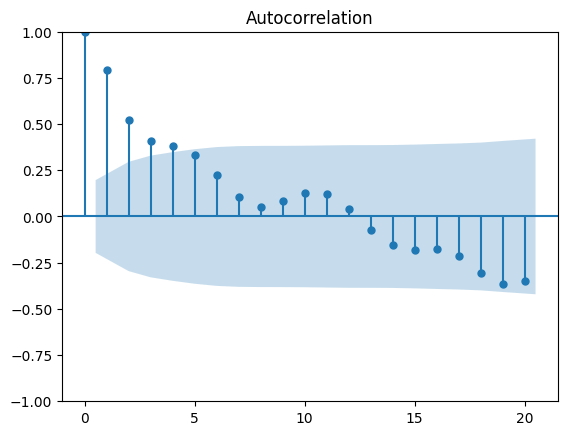

In [8]:
plot_acf(y_diff, lags=20);
plt.show()

Modelimizi uydurma için değerlendirmemiz gereken maksimum değer q = 4 gibi görünüyor. Ancak, Otomatik-ARIMA kullanacak olsaydık (bu konuda daha sonra ayrıntılı bilgi), q=2 kullanmanın ideal sonuçlar verdiğini görürdük, bu nedenle başlangıçta q=2 ayarlamayı deneyelim.

Şüpheniz olduğunda, Y'yi yeterince açıklayan daha basit modeli seçin.

#### AR($\color{red}{p}$) = $Y^{\color{green}{(d)}}$'nin $\color{red}{PACF}$'inin kesildiği gecikme sayısı

AR sırası (`p`), `y_diff`'e uygulanan **k**ısmi otokorelasyon grafiği [`plot_pacf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html) incelenerek bulunabilir.

(Kısmi otokorelasyon, ara gecikmelerin katkılarını hariç tuttuktan sonra seri ile gecikmesi arasındaki korelasyon olarak düşünülebilir. Yani, PACF bir şekilde bir gecikme ile seri arasındaki saf korelasyonu iletir)

👉 `p`'yi belirleyin

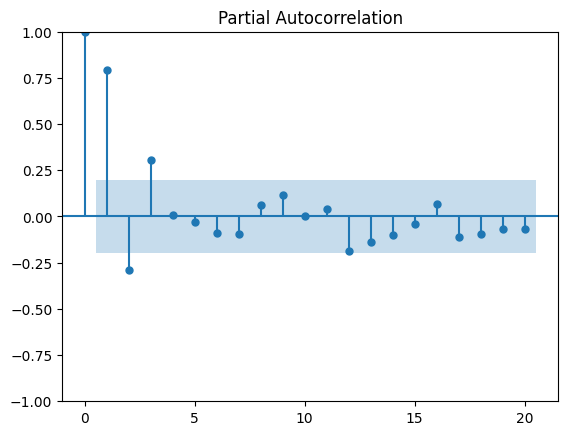

In [9]:
plot_pacf(y_diff, lags=20);
plt.show()

İlk 3 gecikme terimi anlamlılık düzeyinin üstünde göründüğü için `p = 3` seçebiliriz, ancak daha basit bir model `p = 1` ile de gidebiliriz.

### Adım 3 - Modeli oluşturun

Artık ARIMA için `p`, `d` ve `q` değerlerini seçtiğinize göre,

👉 `statsmodels`'den `arima_model`'i oluşturun.
- modeli uydurur
- modeli yazdır (`.summary`)

In [10]:
from statsmodels.tsa.arima.model import ARIMA


model = ARIMA(y, order=(1, 1, 2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -254.126
Date:                Fri, 13 Mar 2026   AIC                            516.253
Time:                        17:43:26   BIC                            526.633
Sample:                             0   HQIC                           520.453
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6976      0.130      5.365      0.000       0.443       0.952
ma.L1          0.4551      0.169      2.699      0.007       0.125       0.786
ma.L2         -0.0664      0.157     -0.424      0.6

☝️ P-değerleriniz çok yüksekse, karşılık gelen AR veya SA katsayılarını azaltarak bu terimleri kaldırmayı deneyin.

[`AIC - Akaike Bilgi Kriteri`](https://medium.com/towardsdatascience/the-akaike-information-criterion-c20c8fd832f2) değerini en aza indirerek uyumunuzun genel performansını değerlendirebilirsiniz

(1,1,1) ARIMA modellerinin aşırı uydurmaya karşı daha az şansı olduğu (p-değerleri düşük kalır) ve diğer modellerden neredeyse benzer bir AIC puanı koruduğu görülüyor

## 3. Model performansını değerlendirin

👉 `plot_predict()` yöntemi ile model tahminlerinizi görselleştirin

- Yöntemin varsayılan parametrelerine, özellikle `dynamic` parametrelerine yakından bakın.
- Modelinizin gerçekte böyle iyi bir performansa sahip olacağını düşünüyor musunuz?

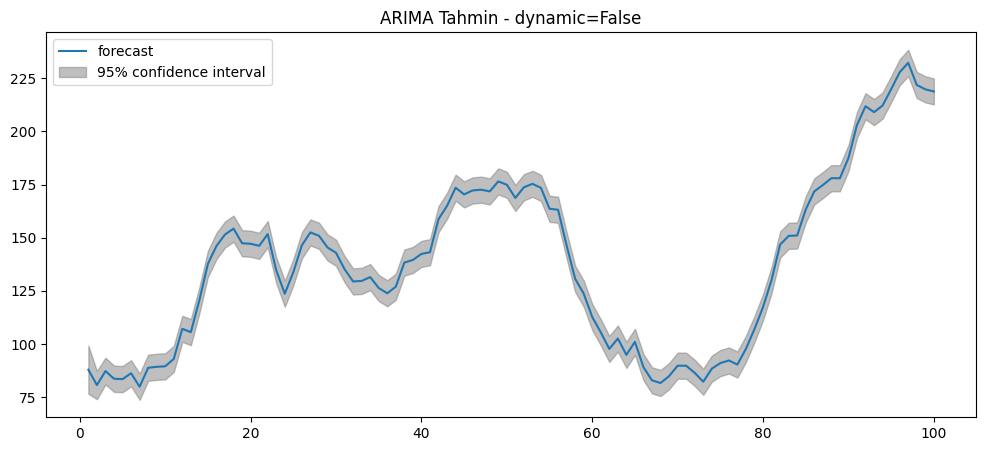

In [11]:
from statsmodels.graphics.tsaplots import plot_predict

fig, axes = plt.subplots(1, 1, figsize=(12, 5))


plot_predict(model_fit, start=1, end=100, dynamic=False, ax=axes)
plt.title('ARIMA Tahmin - dynamic=False')
plt.show()

☝️ `dynamic=False`, `y_pred`'i tahmin etmek için mevcut tüm `y` değerlerini kullanır, bu da ARIMA tahminizin $y_t$'yi tahmin etmek için $y_{t-1}$'e kadar kullanmasını sağlar. Gerçekte, özellikle gelecekte birkaç aralığı tahmin etmek istiyorsanız tüm `y`'ye erişiminiz yoktur.

👉 Modelin yalnızca _85'e kadar verilere erişimi_ olan bir durumda _son 15 değeri_ tahmin eden bir tahmini çizmek için `dynamic=True` kullanmayı deneyin. Yani model:
- gerçek [1...85]'e dayalı olarak 86'yı tahmin eder
- sonra 86 için önceden tahmin ettiği değer _artı_ [1...85]'e dayalı olarak 87'yi tahmin eder
- vb...100'e kadar yinelemeli olarak

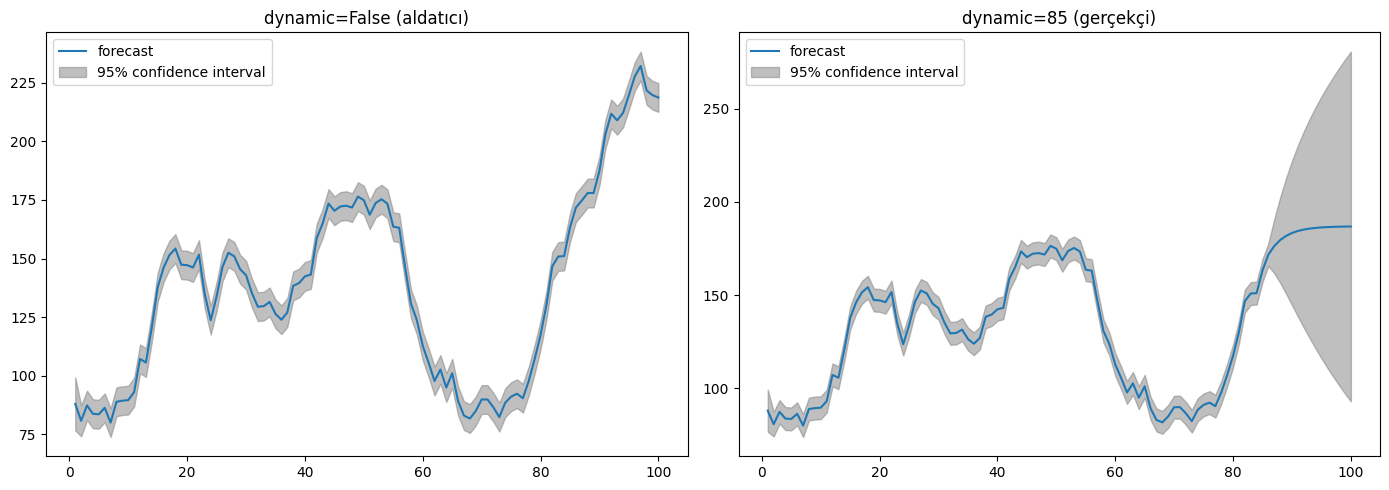

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


plot_predict(model_fit, start=1, end=100, dynamic=False, ax=axes[0])
axes[0].set_title('dynamic=False (aldatıcı)')


plot_predict(model_fit, start=1, end=100, dynamic=85, ax=axes[1])
axes[1].set_title('dynamic=85 (gerçekçi)')

plt.tight_layout()
plt.show()

☝️ Bu hala _gerçek_ bir tahmin değil! Neden?

<details>
    <summary>Cevap</summary>

Modelimiz uyum aşamasında tüm `y_true` serisini "gördü"!
</details>

### 3.1 Örneklem Dışı Tahminler (gerçek "gelecek")

👉 Test seti için yalnızca son 15 veri noktasını tutarak bir eğitim-test bölümü oluşturun ve ARIMA'nızı yalnızca eğitim setinde eğitin.

In [13]:

train = y[:85]
test = y[85:]


model_train = ARIMA(train, order=(1, 1, 1))
model_train_fit = model_train.fit()

print(f'Train boyutu: {len(train)}')
print(f'Test boyutu: {len(test)}')

Train boyutu: 85
Test boyutu: 15


👉 Şimdi 85. adımdayız ve geleceği hiç görmedik:
- Sonraki 15 veri noktasını (yani eğitim veri setinizin sonundan sonrasını) "tahmin etmek" için uydurduğunuz `arima` modelinde `get_forecast()` yöntemini kullanın

Yöntem `statsmodels`'den bir `PredictionResultsWrapper` nesnesi döndürür.

**💻 Bu sonucu `forecast_results` adlı bir değişkende saklayın.**

İlk başta gezinmek zordur, ancak işte bazı ipuçları:
- Tahminlerinizi `forecast_results.predicted_mean`'de bulabilirsiniz
- Güven aralıklarınız `forecast_results.conf_int()` tarafından verilir

In [14]:

forecast_results = model_train_fit.get_forecast(steps=15)


predicted_mean = forecast_results.predicted_mean
conf_int = forecast_results.conf_int()

print("Tahminler:")
print(predicted_mean)
print("\nGüven Aralıkları:")
print(conf_int)

Tahminler:
85    163.161121
86    167.885191
87    171.001580
88    173.057410
89    174.413606
90    175.308265
91    175.898457
92    176.287796
93    176.544637
94    176.714071
95    176.825843
96    176.899577
97    176.948219
98    176.980306
99    177.001474
Name: predicted_mean, dtype: float64

Güven Aralıkları:
    lower value  upper value
85   156.929245   169.392997
86   153.134449   182.635933
87   147.668958   194.334202
88   141.542363   204.572457
89   135.260008   213.567203
90   129.075688   221.540842
91   123.110756   228.686158
92   117.415455   235.160138
93   112.002054   241.087220
94   106.863176   246.564965
95   101.982007   251.669679
96    97.337943   256.461212
97    92.909656   260.986782
98    88.676665   265.283948
99    84.620084   269.382865


👉 Tahmin edilen değerleri ve ayrıca %95 belirsizlik aralığının üst ve alt aralığını çizin

👉 Model performansını geçmişe göre daha iyi kavramak için önceki 85 `y` gerçek veri noktanızı da çizmeyi deneyin

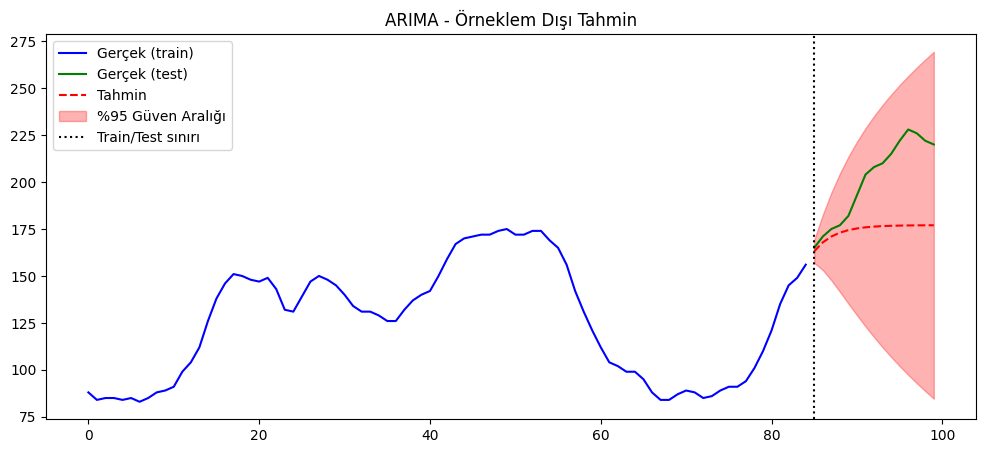

In [15]:
plt.figure(figsize=(12, 5))


plt.plot(train.index, train, label='Gerçek (train)', color='blue')


plt.plot(test.index, test, label='Gerçek (test)', color='green')


plt.plot(predicted_mean.index, predicted_mean, 
         label='Tahmin', linestyle='--', color='red')


plt.fill_between(conf_int.index,
                 conf_int['lower value'],
                 conf_int['upper value'],
                 alpha=0.3, color='red', label='%95 Güven Aralığı')

plt.axvline(x=85, color='black', linestyle=':', label='Train/Test sınırı')
plt.legend()
plt.title('ARIMA - Örneklem Dışı Tahmin')
plt.show()

### 3.2 %95 güven aralığınıza güvenebilir misiniz? (çıkarım koşulları)

👉 Hiçbir örüntü olmadığından emin olmak için artıkları `model.resid` çizin
- Normal dağılım
- Sıfır ortalama
- Tekdüze varyans
- Oto-regresif örüntü yok (isterseniz artıkları plot_acf yapabilirsiniz)

Not: artıklar `plot_predict(dynamic=False)`'daki gibi tüm verileri 'görerek' oluşturulur

Ayrıca, artıkların yaklaşık olarak normal dağılımda olup olmadığını görmek için artıkların bir histogramını veya KDE uyumunu çizmeyi deneyin.

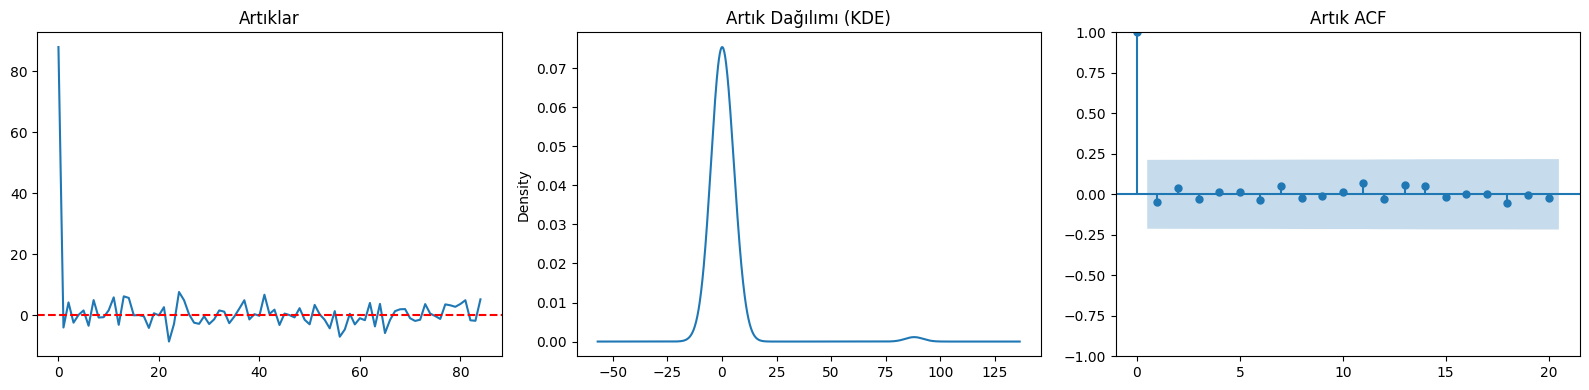

Artık Ortalama: 1.2665
Artık Std: 10.0420


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))


model_train_fit.resid.plot(ax=axes[0], title='Artıklar')
axes[0].axhline(y=0, color='red', linestyle='--')


model_train_fit.resid.plot(kind='kde', ax=axes[1], title='Artık Dağılımı (KDE)')


plot_acf(model_train_fit.resid, lags=20, ax=axes[2], title='Artık ACF')

plt.tight_layout()
plt.show()

print(f'Artık Ortalama: {model_train_fit.resid.mean():.4f}')
print(f'Artık Std: {model_train_fit.resid.std():.4f}')

## 3.3 Çapraz doğrulanmış performans ölçümleri

👉 Aşağıda zaman serileri için en yaygın performans ölçümleri yer almaktadır

In [17]:
import numpy as np
from statsmodels.tsa.stattools import acf

def forecast_accuracy(y_pred: pd.Series, y_true: pd.Series) -> float:

    mape = np.mean(np.abs(y_pred - y_true)/np.abs(y_true))  # Mean Absolute Percentage Error
    me = np.mean(y_pred - y_true)             # ME
    mae = np.mean(np.abs(y_pred - y_true))    # MAE
    mpe = np.mean((y_pred - y_true)/y_true)   # MPE
    rmse = np.mean((y_pred - y_true)**2)**.5  # RMSE
    corr = np.corrcoef(y_pred, y_true)[0,1]   # Correlation between the Actual and the Forecast
    mins = np.amin(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    maxs = np.amax(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(y_pred-y_true, fft=False)[1]                      # Lag 1 Autocorrelation of Error

    forecast = ({
        'mape':mape,
        'me':me,
        'mae': mae,
        'mpe': mpe,
        'rmse':rmse,
        'acf1':acf1,
        'corr':corr,
        'minmax':minmax
    })

    return forecast

👉 ARIMA hiper-parametrelerinizle oynayın ve tahmin performansınız üzerindeki etkisini görün

In [19]:
from itertools import product


p_values = [0, 1, 2, 3]
d_values = [1]
q_values = [0, 1, 2, 3]

best_aic = float('inf')
best_order = None

for p, d, q in product(p_values, d_values, q_values):
    try:
        model = ARIMA(train, order=(p, d, q))
        result = model.fit()
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = (p, d, q)
        print(f'ARIMA{(p,d,q)} → AIC: {result.aic:.2f}')
    except:
        pass

print(f'\n🏆 En iyi model: ARIMA{best_order} → AIC: {best_aic:.2f}')

ARIMA(0, 1, 0) → AIC: 534.09
ARIMA(0, 1, 1) → AIC: 468.81
ARIMA(0, 1, 2) → AIC: 445.68
ARIMA(0, 1, 3) → AIC: 446.48
ARIMA(1, 1, 0) → AIC: 449.46
ARIMA(1, 1, 1) → AIC: 440.11
ARIMA(1, 1, 2) → AIC: 441.94


/home/demet/.pyenv/versions/3.12.9/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(1, 1, 3) → AIC: 442.18
ARIMA(2, 1, 0) → AIC: 444.91
ARIMA(2, 1, 1) → AIC: 442.05
ARIMA(2, 1, 2) → AIC: 443.52
ARIMA(2, 1, 3) → AIC: 443.29
ARIMA(3, 1, 0) → AIC: 440.33
ARIMA(3, 1, 1) → AIC: 442.03
ARIMA(3, 1, 2) → AIC: 442.25
ARIMA(3, 1, 3) → AIC: 442.07

🏆 En iyi model: ARIMA(1, 1, 1) → AIC: 440.11


/home/demet/.pyenv/versions/3.12.9/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 4 Izgara Arama

`pmdarima` kullanarak (p,d,q) için bir Izgara Arama çalıştırmayı deneyin. En azından şunları kullanın:
- `test='adf'`
- `trace=True`
- `error_action='ignore'`
- `suppress_warnings=True`

In [21]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [24]:
import pmdarima as pm

model = pm.auto_arima(
    train, 
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,
    test='adf',
    trace=True, error_action='ignore', suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=449.662, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=449.569, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=445.819, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=445.820, Time=0.02 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=441.300, Time=0.02 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(0,2,3)(0,0,0)[0]             : AIC=438.613, Time=0.04 sec
 ARIMA(1,2,3)(0,0,0)[0]             : AIC=440.036, Time=0.06 sec
 ARIMA(0,2,3)(0,0,0)[0] intercept   : AIC=440.231, Time=0.04 sec

Best model:  ARIMA(0,2,3)(0,0,0)[0]          
Total fit time: 0.402 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   85
Model:               SARIMAX(0, 2, 3)   Log Likelihood                -215.307
Date:                Fri, 13 Mar 2026   AIC                   

## (İsteğe bağlı) Modelinizin Performansını Çapraz Doğrulayın

Pratikte, sonuçlar ve Izgara Arama her zaman çapraz doğrulanmalıdır:

Modelinizin performansını gerçekten değerlendirmek ve çapraz doğrulamadan sonra en iyi hiperparametreleri bulmak için bitişik K-katlar oluşturmak amacıyla [`sklearn.model_selection.TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) kullanmaktan çekinmeyin.

<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_013.png'>

**ARIMA - TimeSeriesSplit + Izgara Arama kullanarak Çapraz Doğrulama**

In [ ]:
# YOUR CODE HERE

In [ ]:
df.sort_values('AIC').groupby('(p, d, q)').mean()['AIC'].sort_values()

☝️ İlk model seçimimiz (1, 1, 2) çok da kötü değil!
Veri seti (100 veri noktası) gerçekte herhangi bir şeyi çapraz doğrulamak için çok küçük olduğuna dikkat edin!